In [1]:
import numpy as np

def red_panda_optimization(obj_func, lb, ub, dim, pop_size, max_iter):
    """
    Red Panda Optimization (RPO) Algorithm

    Parameters:
    obj_func : callable : The objective function to minimize.
    lb       : float or array : Lower bound of the search space.
    ub       : float or array : Upper bound of the search space.
    dim      : int : Number of dimensions.
    pop_size : int : Population size (number of red pandas).
    max_iter : int : Maximum number of iterations.

    Returns:
    global_best_pos : array : The best solution found.
    global_best_fit : float : The fitness of the best solution.
    convergence     : list  : Fitness history over iterations.
    """
    # Convert bounds to numpy arrays if they are scalars
    if not isinstance(lb, np.ndarray):
        lb = np.full(dim, lb)
        ub = np.full(dim, ub)

    # Initialize population randomly within bounds
    pop = np.random.uniform(0, 1, (pop_size, dim)) * (ub - lb) + lb

    # Evaluate initial fitness
    fitness = np.array([obj_func(ind) for ind in pop])

    # Track the global best
    best_idx = np.argmin(fitness)
    global_best_pos = pop[best_idx].copy()
    global_best_fit = fitness[best_idx]

    convergence = np.zeros(max_iter)

    for t in range(1, max_iter + 1):
        for i in range(pop_size):

            # ---------------------------------------------------
            # Phase 1: Exploration (Foraging Strategy)
            # ---------------------------------------------------
            # Randomly select a "food source" (another panda in the population)
            k = np.random.randint(pop_size)
            while k == i:
                k = np.random.randint(pop_size)

            SF = pop[k]          # Selected Food source
            F_SF = fitness[k]    # Fitness of the food source

            # 'I' is a random variable that dictates search intensity
            I = np.random.choice([1, 2])
            r1 = np.random.rand(dim)

            # Move towards the food if it's better, otherwise move away
            if F_SF < fitness[i]:
                new_pos_P1 = pop[i] + r1 * (SF - I * pop[i])
            else:
                new_pos_P1 = pop[i] + r1 * (pop[i] - SF)

            # Boundary check
            new_pos_P1 = np.clip(new_pos_P1, lb, ub)
            fit_P1 = obj_func(new_pos_P1)

            # Update position if the new one is better
            if fit_P1 < fitness[i]:
                pop[i] = new_pos_P1
                fitness[i] = fit_P1

            # ---------------------------------------------------
            # Phase 2: Exploitation (Climbing Trees)
            # ---------------------------------------------------
            # Perform a localized search that shrinks over time (t)
            r2 = np.random.rand(dim)

            # The perturbation shrinks as iterations increase to fine-tune the solution
            new_pos_P2 = pop[i] + ((1 - 2 * r2) * (ub - lb)) / t

            # Boundary check
            new_pos_P2 = np.clip(new_pos_P2, lb, ub)
            fit_P2 = obj_func(new_pos_P2)

            # Update position if the new one is better
            if fit_P2 < fitness[i]:
                pop[i] = new_pos_P2
                fitness[i] = fit_P2

            # Update global best
            if fitness[i] < global_best_fit:
                global_best_fit = fitness[i]
                global_best_pos = pop[i].copy()

        # Record the best fitness of the current iteration
        convergence[t-1] = global_best_fit

    return global_best_pos, global_best_fit, convergence

Best Score: 9.379171329558216e-41
Best Position: [-2.33223311e-21  2.44436026e-22  2.98346880e-21 -1.94157954e-21
  3.78755104e-21  4.69165146e-21  2.88963388e-22 -2.98476579e-21
  1.39050326e-21 -5.32342686e-21]


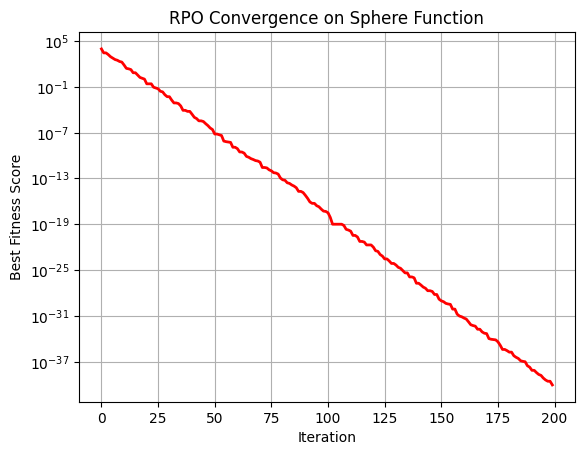

In [2]:
import matplotlib.pyplot as plt

# 1. Define the objective function (Sphere Function)
def sphere_function(x):
    return np.sum(x**2)

# 2. Set up algorithm parameters
dimensions = 10
lower_bound = -100.0
upper_bound = 100.0
population_size = 30
maximum_iterations = 200

# 3. Run the algorithm
best_position, best_score, history = red_panda_optimization(
    obj_func=sphere_function,
    lb=lower_bound,
    ub=upper_bound,
    dim=dimensions,
    pop_size=population_size,
    max_iter=maximum_iterations
)

print(f"Best Score: {best_score}")
print(f"Best Position: {best_position}")

# 4. Plot the convergence curve
plt.plot(history, color='red', linewidth=2)
plt.title('RPO Convergence on Sphere Function')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness Score')
plt.yscale('log') # Log scale is often better for evaluating optimization curves
plt.grid(True)
plt.show()